In [5]:
import pandas as pd
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Create sample hiring dataset
data = pd.DataFrame({
    "gender": ["Male", "Female", "Male", "Female", "Male", "Female", "Male", "Female"],
    "experience": [5, 3, 6, 2, 7, 4, 8, 1],
    "selected": [1, 0, 1, 0, 1, 0, 1, 0]
})

# Convert gender to numeric
data["gender"] = data["gender"].map({"Male": 1, "Female": 0})

X = data[["gender", "experience"]]
y = data["selected"]

# Train model
model = LogisticRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Fairness metric
metric = MetricFrame(
    metrics=selection_rate,
    y_true=y,
    y_pred=y_pred,
    sensitive_features=data["gender"]
)

print("Selection Rate by Gender:")
print(metric.by_group)

Selection Rate by Gender:
gender
0    0.0
1    1.0
Name: selection_rate, dtype: float64


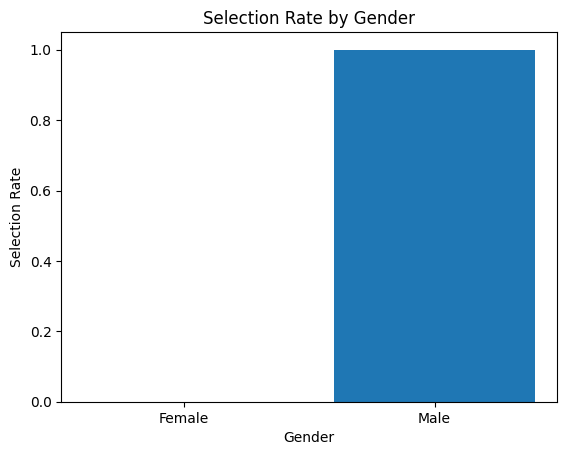

In [6]:
import matplotlib.pyplot as plt

groups = ["Female", "Male"]
selection_rates = [0.0, 1.0]

plt.bar(groups, selection_rates)
plt.xlabel("Gender")
plt.ylabel("Selection Rate")
plt.title("Selection Rate by Gender")
plt.show()

# AI Fairness Report – Hiring Bias

## Project: Hiring Bias Detection

## Objective:
To evaluate whether a hiring model shows bias based on gender.

## Tool Used:
Fairlearn

## Result:
- Male selection rate: 1.0
- Female selection rate: 0.0

## Conclusion:
The model is biased towards male candidates.

## Recommendation:
- Remove gender feature
- Apply fairness constraints
- Regular bias audits

## Methodology:
A logistic regression model was trained on a small hiring dataset.
Fairness was evaluated using selection rate across gender groups.

## Risk & Impact:
Bias in hiring systems can lead to discrimination and unfair rejection of qualified candidates, especially affecting underrepresented groups.

## Future Improvements:
- Remove sensitive attributes like gender
- Use fairness-aware models
- Increase dataset diversity